In [3]:
!pip install datasets sacrebleu transformers sentencepiece matplotlib

In [4]:
# Load WMT14 fr-en validation subset
from datasets import load_dataset

dataset = load_dataset("wmt14", "fr-en", split="validation[:200]")
dataset = dataset.shuffle(seed=42)

src_texts = [item["translation"]["en"] for item in dataset]
tgt_texts = [item["translation"]["fr"] for item in dataset]

print("Sample EN:", src_texts[0])
print("Sample FR:", tgt_texts[0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/30 [00:00<?, ?it/s]

fr-en/train-00000-of-00030.parquet:   0%|          | 0.00/252M [00:00<?, ?B/s]

fr-en/train-00001-of-00030.parquet:   0%|          | 0.00/241M [00:00<?, ?B/s]

...

fr-en/test-00000-of-00001.parquet:   0%|          | 0.00/536k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/40836715 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3003 [00:00<?, ? examples/s]

Sample EN: "They gave me five years to live, I've made it to seven," he says, with mixed emotions, lying in his bed at the Victor-Gadbois palliative care home in Beloeil, where he arrived the previous day.
Sample FR: " Ils m'avaient donné cinq ans à vivre, j'ai fait sept ans ", dit-il, mi-figue mi-raisin, allongé dans son lit à la maison de soins palliatifs Victor-Gadbois, de Beloeil, où il est arrivé la veille.


In [5]:
# Load the MarianMT model
from transformers import MarianTokenizer, MarianMTModel
import torch
import time

model_name = "Helsinki-NLP/opus-mt-en-fr"
tokenizer = MarianTokenizer.from_pretrained(model_name)
model = MarianMTModel.from_pretrained(model_name)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

print("Using device:", device)

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/778k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


pytorch_model.bin:   0%|          | 0.00/301M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

Using device: cuda


In [6]:
# Define performance evaluation function
import sacrebleu
from tqdm import tqdm

def evaluate_model(texts, references):
    predictions = []
    times = []

    for text in tqdm(texts):
        # Tokenization
        inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True).to(device)

        # Measure inference time
        start = time.time()
        translated = model.generate(**inputs)
        end = time.time()

        times.append(end - start)

        decoded = tokenizer.decode(translated[0], skip_special_tokens=True)
        predictions.append(decoded)

    # BLEU score
    bleu = sacrebleu.corpus_bleu(predictions, [references]).score

    return predictions, bleu, times

In [7]:
# Evaluate performance
preds, bleu_score, inference_times = evaluate_model(src_texts, tgt_texts)

print("BLEU Score:", bleu_score)
print("Average Inference Time:", sum(inference_times) / len(inference_times), "seconds")

  0%|          | 0/200 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/301M [00:00<?, ?B/s]

100%|██████████| 200/200 [00:58<00:00,  3.43it/s]

BLEU Score: 52.29285287795771
Average Inference Time: 0.28868374824523924 seconds


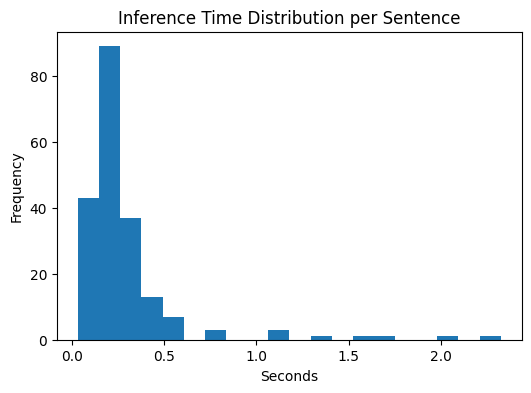

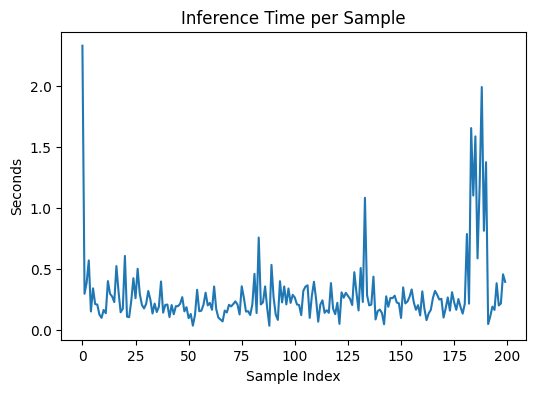

In [8]:
import matplotlib.pyplot as plt

# Figure 1: Inference Time Distribution
plt.figure(figsize=(6,4))
plt.hist(inference_times, bins=20)
plt.title("Inference Time Distribution per Sentence")
plt.xlabel("Seconds")
plt.ylabel("Frequency")
plt.show()

# Figure 2: Inference Time Trend
plt.figure(figsize=(6,4))
plt.plot(inference_times)
plt.title("Inference Time per Sample")
plt.xlabel("Sample Index")
plt.ylabel("Seconds")
plt.show()

In [9]:
import pandas as pd

df = pd.DataFrame({
    "Metric": ["BLEU Score", "Avg Inference Time (s)"],
    "Value": [bleu_score, sum(inference_times)/len(inference_times)]
})

df

,Metric,Value
0,BLEU Score,52.292853
1,Avg Inference Time (s),0.288684
